# Modular Time-Series Notebook Toolkit – Full Demo

**`aic_ts_suite`** — Interactive R&D extension bridging raw data ingestion and advanced predictive modelling.

This notebook walks through every module of the toolkit:

| # | Section | Module |
|---|---------|--------|
| 1 | Configuration & Traceability | `config` |
| 2 | Data Ingestion & Connectivity | `connectivity` |
| 3 | Data Cleaning & Sanitisation | `cleaning` |
| 4 | Variance-Stabilising Transforms | `signals.transforms` |
| 5 | EDA Visualisation | `viz` |
| 6 | Feature Engineering (Fourier, MAs, Lags) | `features` |
| 7 | Univariate Forecasting | `forecasting.univariate` |
| 7b | XGBoost Forecasting | `forecasting.ml_models` |
| 7c | Prophet Forecasting | `forecasting.ml_models` |
| 8 | Multivariate Forecasting (VAR) | `forecasting.multivariate` |
| 9 | Neural & Foundation Models | `forecasting.neural` |
| 10 | KPI Evaluation & Comparison | `evaluation` |
| 11 | Styled Display & Metric Cards | `display` |

---
## 0 — Setup & Imports

In [9]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Ensure the toolkit package is importable
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print('Environment ready.')

Environment ready.


---
## 1 — Configuration & Traceability

Every notebook-initiated run propagates a **correlationId** (UUID v4) for end-to-end traceability.

In [10]:
from aic_ts_suite.config import CONFIG

print(f"Correlation ID : {CONFIG.correlation_id}")
print(f"TimescaleDB DSN: {CONFIG.timescale.dsn}")
print(f"Confidence     : {CONFIG.confidence_level*100:.0f} %")
print(f"Sanitise strat : {CONFIG.default_sanitize_strategy}")

Correlation ID : c288d469-d7d9-4a19-81f2-c0b709091dd3
TimescaleDB DSN: postgresql://readonly:@10.20.0.10:5432/tsdb
Confidence     : 95 %
Sanitise strat : interpolate


---
## 2 — Data Ingestion (Synthetic Demo Data)

We generate a synthetic monthly time-series with trend, seasonality, and random noise.  
In production this would be replaced by `TimescaleClient.fetch_sensor()` or `read_csv()` / `read_excel()`.

In [11]:
from aic_ts_suite.connectivity.models import TimeSeriesObservation

# ── Synthetic data: 10 years of monthly observations ──
np.random.seed(CONFIG.random_state)
n = 120  # 10 years
dates = pd.date_range('2016-01-01', periods=n, freq='MS')
trend = np.linspace(50, 90, n)
seasonal = 10 * np.sin(2 * np.pi * np.arange(n) / 12)
noise = np.random.normal(0, 2, n)
values = trend + seasonal + noise

# Inject 5 % missing values
mask = np.random.rand(n) < 0.05
values[mask] = np.nan

raw_df = pd.DataFrame({'timestamp': dates, 'temperature': values})
print(f"Raw shape: {raw_df.shape}  |  NaN count: {raw_df['temperature'].isna().sum()}")
raw_df.head(10)

Raw shape: (120, 2)  |  NaN count: 6


,timestamp,temperature
0,2016-01-01,50.993428
1,2016-02-01,55.059606
2,2016-03-01,60.627900
3,2016-04-01,64.054463
4,2016-05-01,59.536485
5,2016-06-01,56.212398
6,2016-07-01,55.175232
7,2016-08-01,48.887811
8,2016-09-01,43.089873
9,2016-10-01,44.110330


### 2.1 — TimeSeriesObservation model

In [12]:
# Convert the first row into the platform-standard observation envelope
obs = TimeSeriesObservation.from_datetime(
    timestamp=dates[0], value=float(values[0] if not np.isnan(values[0]) else 0), series_id='sensor_42'
)
print(obs)
print(f"  → epoch ms : {obs.timestamp_ms}")
print(f"  → UTC dt   : {obs.datetime_utc}")

TimeSeriesObservation(timestamp_ms=1451606400000, value=50.993428306022466, series_id='sensor_42')
  → epoch ms : 1451606400000
  → UTC dt   : 2016-01-01 00:00:00+00:00


---
## 3 — Data Cleaning & Sanitisation

In [13]:
from aic_ts_suite.cleaning import sanitize

# Strategy 1: linear interpolation (default)
clean_df = sanitize(raw_df, strategy='interpolate')

print(f"NaN after interpolate: {clean_df['temperature'].isna().sum()}")
clean_df.head()

NaN after interpolate: 0


,timestamp,temperature
0,2016-01-01,50.993428
1,2016-02-01,55.059606
2,2016-03-01,60.627900
3,2016-04-01,64.054463
4,2016-05-01,59.536485


In [14]:
# Strategy 2: forward-fill
ffill_df = sanitize(raw_df, strategy='ffill')
print(f"NaN after ffill: {ffill_df['temperature'].isna().sum()}")

NaN after ffill: 0


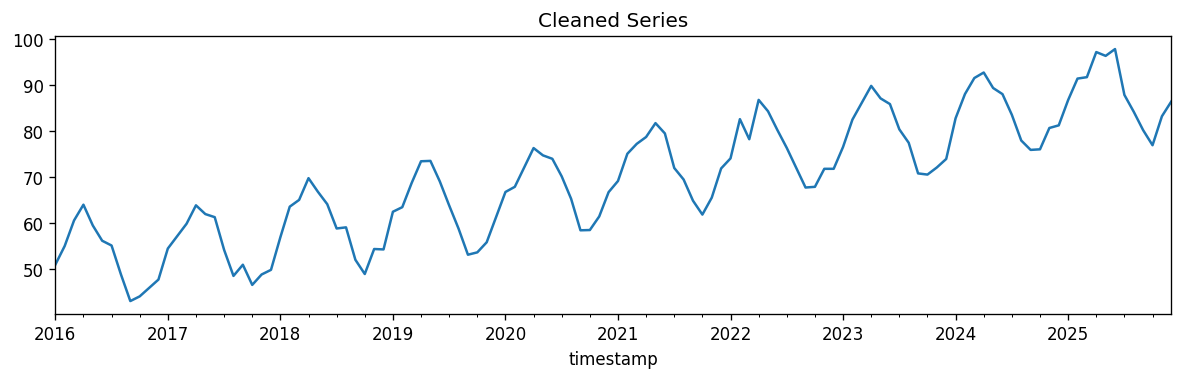

In [15]:
# ── Prepare a datetime-indexed Series for downstream modules ──
ts = clean_df.set_index('timestamp')['temperature']
ts.name = 'Temperature'
ts.plot(figsize=(12, 3), title='Cleaned Series');

### 3.1 — Timestamp Normalisation to Epoch Milliseconds

In [16]:
import tempfile, os
from aic_ts_suite.cleaning import DataCleaner

# Save a temp CSV to demonstrate the full DataCleaner pipeline
_tmp_csv = os.path.join(tempfile.gettempdir(), 'demo_sensor.csv')
raw_df.to_csv(_tmp_csv, index=False)

pipeline_df = (
    DataCleaner(_tmp_csv, timestamp_col='timestamp')
    .load()
    .sanitize('interpolate')
    .to_epoch_ms()
    .result()
)
pipeline_df[['timestamp', 'temperature', 'timestamp_ms']].head()


,timestamp,temperature,timestamp_ms
0,2016-01-01,50.993428,1451606400
1,2016-02-01,55.059606,1454284800
2,2016-03-01,60.627900,1456790400
3,2016-04-01,64.054463,1459468800
4,2016-05-01,59.536485,1462060800


---
## 4 — Variance-Stabilising Transforms

Box-Cox λ (MLE) = 0.7964


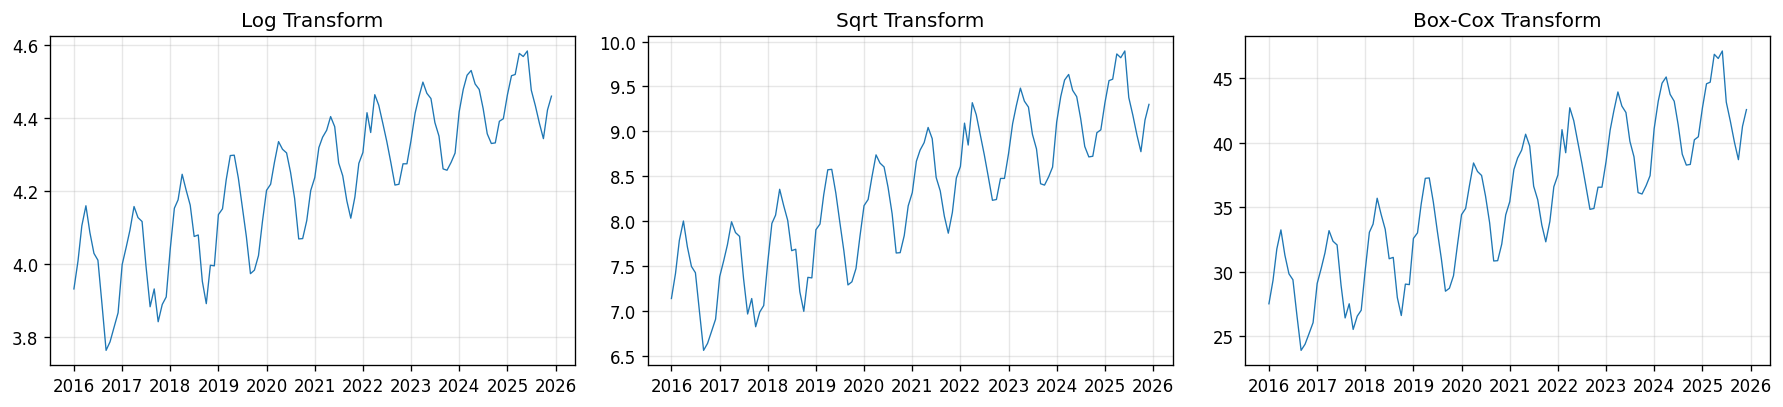

In [17]:
from aic_ts_suite.signals.transforms import LogTransform, SqrtTransform, BoxCoxTransform

log_t  = LogTransform()
sqrt_t = SqrtTransform()
bc_t   = BoxCoxTransform()

ts_log  = log_t.apply(ts)
ts_sqrt = sqrt_t.apply(ts)
ts_bc   = bc_t.apply(ts)

print(f"Box-Cox λ (MLE) = {bc_t.lmbda:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, transformed, label in zip(axes, [ts_log, ts_sqrt, ts_bc], ['Log', 'Sqrt', 'Box-Cox']):
    ax.plot(transformed, linewidth=0.8)
    ax.set_title(f'{label} Transform')
    ax.grid(True, alpha=0.3)
fig.tight_layout()

In [18]:
# Verify round-trip (inverse recovers original)
ts_recovered = bc_t.inverse(ts_bc)
roundtrip_error = (ts - ts_recovered).abs().max()
print(f"Box-Cox round-trip max error: {roundtrip_error:.2e}")

Box-Cox round-trip max error: 4.26e-14


---
## 5 — Exploratory Data Analysis (EDA) Visualisation

### 5.1 — Seasonal Plot

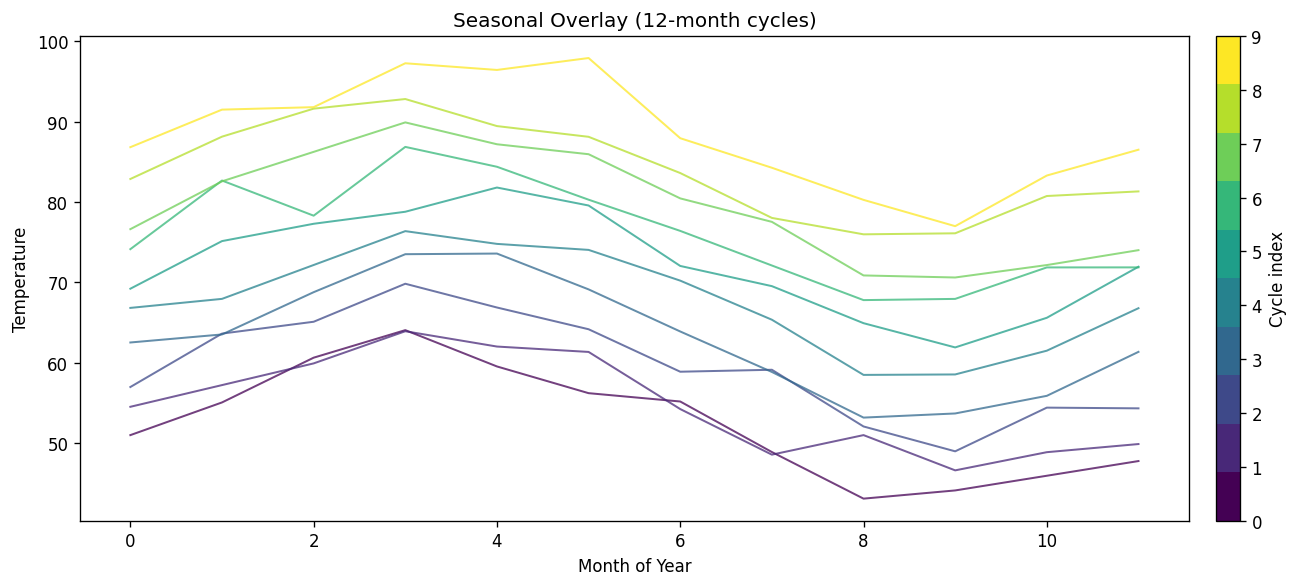

In [19]:
from aic_ts_suite.viz import plot_seasonal

plot_seasonal(ts, period=12, freq_label='Month of Year', title='Seasonal Overlay (12-month cycles)');

### 5.2 — ACF / PACF

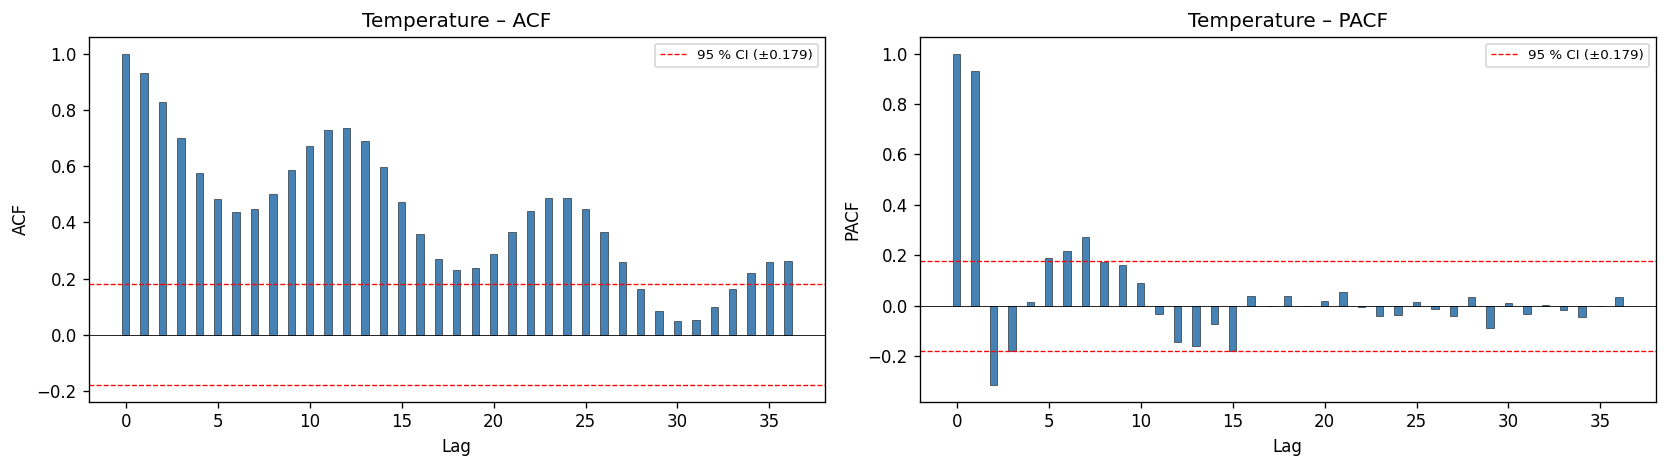

In [20]:
from aic_ts_suite.viz import plot_acf_pacf

plot_acf_pacf(ts, lags=36, title_prefix='Temperature – ');

### 5.3 — Classical Decomposition  (Y = T + S + R)

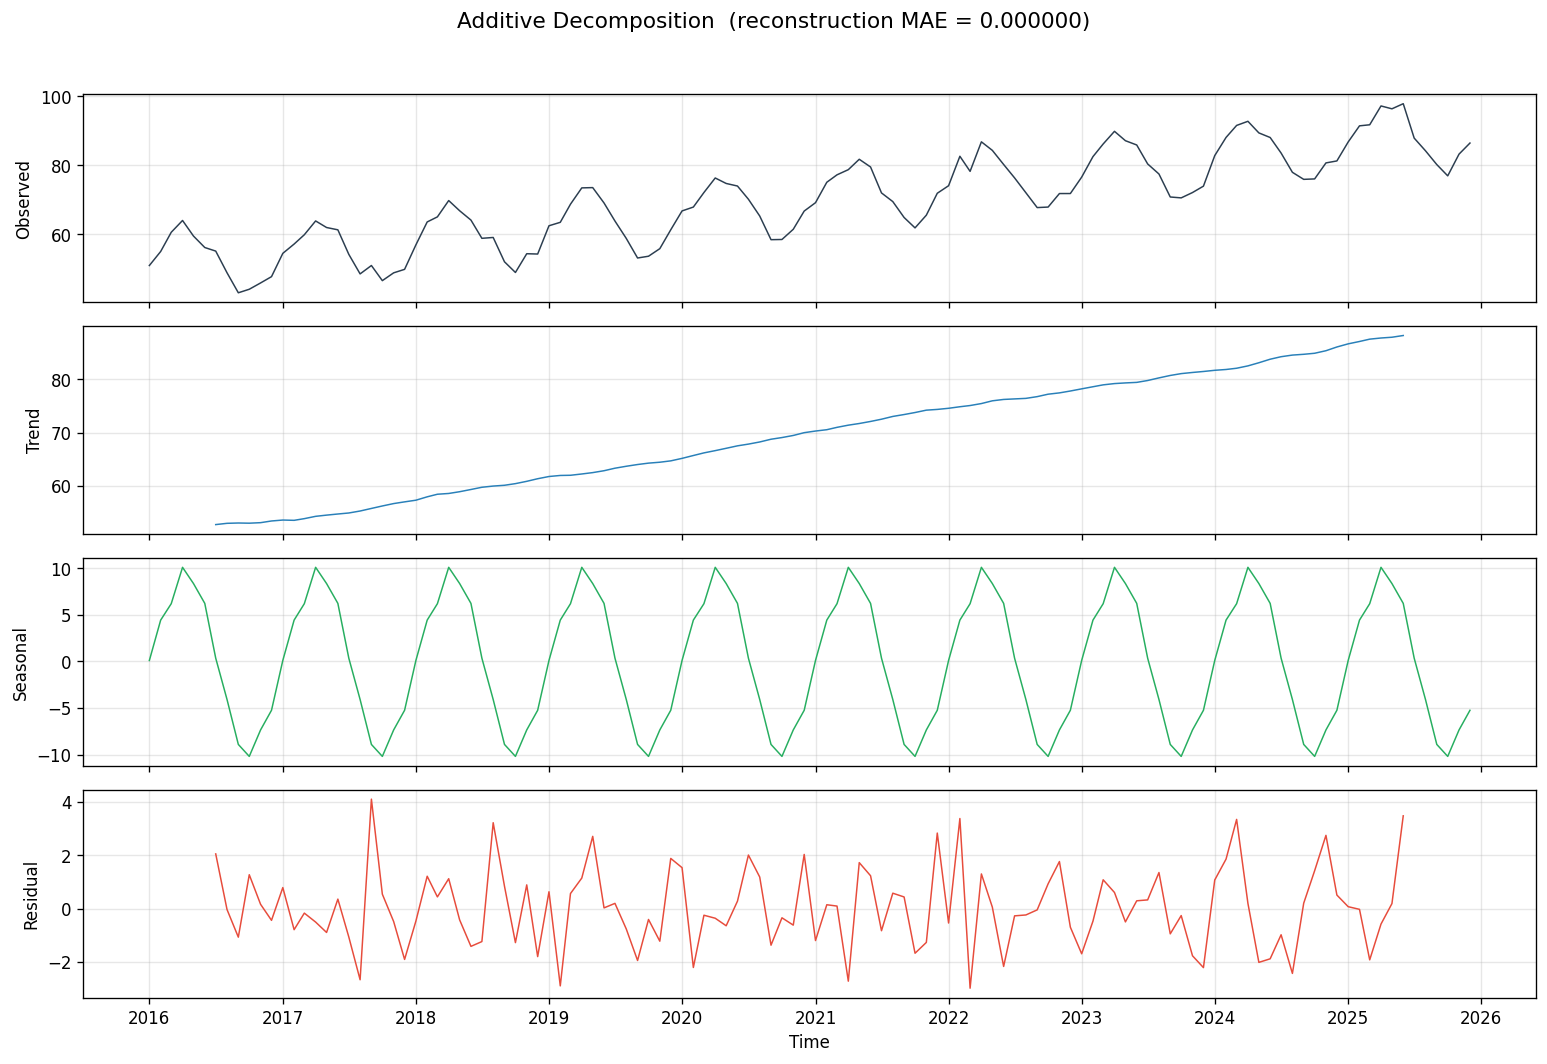

In [21]:
from aic_ts_suite.viz import plot_decomposition

plot_decomposition(ts, period=12, model='additive', title='Additive Decomposition');

---
## 6 — Feature Engineering for XGBoost

### 6.1 — Fourier Harmonic Terms

In [22]:
from aic_ts_suite.features import fourier_terms, optimal_k

# Use the weekly-annual period (52.18 weeks / year) as an example
K_star = optimal_k(ts, period=12, max_K=6)
print(f"Optimal K for period=12: {K_star}")

ft = fourier_terms(n=len(ts), period=12, K=K_star)
ft.index = ts.index
ft.head()

Optimal K for period=12: 1


,sin_1,cos_1
timestamp,,
2016-01-01,0.500000,8.660254e-01
2016-02-01,0.866025,5.000000e-01
2016-03-01,1.000000,6.123234e-17
2016-04-01,0.866025,-5.000000e-01
2016-05-01,0.500000,-8.660254e-01


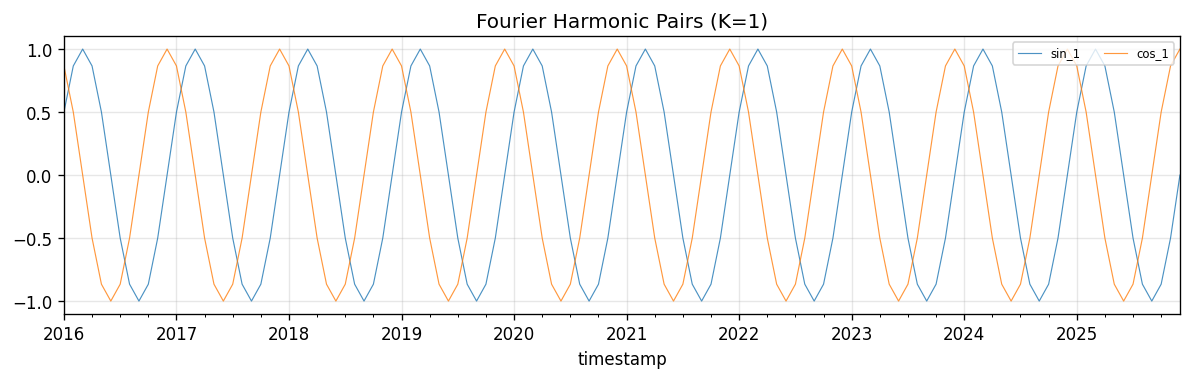

In [23]:
fig, ax = plt.subplots(figsize=(12, 3))
ft.plot(ax=ax, linewidth=0.7, alpha=0.8)
ax.set_title(f'Fourier Harmonic Pairs (K={K_star})')
ax.legend(ncol=K_star*2, fontsize=7)
ax.grid(True, alpha=0.3);

### 6.2 — Moving Averages

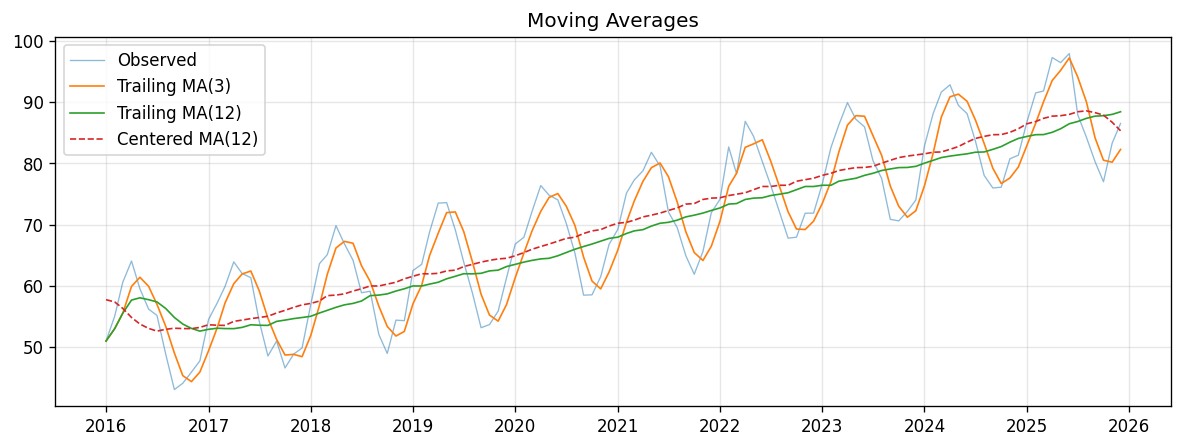

In [24]:
from aic_ts_suite.features import trailing_moving_average, centered_moving_average

trail_3 = trailing_moving_average(ts, window=3)
trail_12 = trailing_moving_average(ts, window=12)
center_12 = centered_moving_average(ts, window=12)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts, label='Observed', alpha=0.5, linewidth=0.8)
ax.plot(trail_3, label='Trailing MA(3)', linewidth=1)
ax.plot(trail_12, label='Trailing MA(12)', linewidth=1)
ax.plot(center_12, label='Centered MA(12)', linewidth=1, linestyle='--')
ax.legend()
ax.set_title('Moving Averages')
ax.grid(True, alpha=0.3);

### 6.3 — Lag Features for Supervised ML

Build a supervised regression matrix from the univariate series using lag columns, rolling statistics, and Fourier terms. This matrix is consumed by `XGBoostForecaster` automatically, but you can also build it manually.

In [25]:
from aic_ts_suite.features import lag_features, rolling_lag_features, build_supervised_matrix

# Individual lag columns
lags_df = lag_features(ts, lags=6)
print("Lag features shape:", lags_df.shape)
display(lags_df.head(8))

# Rolling statistics (mean & std over multiple windows)
roll_df = rolling_lag_features(ts, windows=[3, 6, 12])
print("\nRolling features shape:", roll_df.shape)
display(roll_df.head(8))

# Full supervised matrix (lags + rolling + Fourier) — ready for XGBoost
sup = build_supervised_matrix(ts, lags=12, rolling_windows=[3, 6, 12], fourier_k=4, seasonal_period=12)
print(f"\nSupervised matrix: {sup.shape[0]} rows × {sup.shape[1]} columns")
print("Columns:", list(sup.columns))
display(sup.tail(5))

Lag features shape: (120, 7)


,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6
timestamp,,,,,,,
2016-01-01,50.993428,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-01,55.059606,50.993428,NaN,NaN,NaN,NaN,NaN
2016-03-01,60.627900,55.059606,50.993428,NaN,NaN,NaN,NaN
2016-04-01,64.054463,60.627900,55.059606,50.993428,NaN,NaN,NaN
2016-05-01,59.536485,64.054463,60.627900,55.059606,50.993428,NaN,NaN
2016-06-01,56.212398,59.536485,64.054463,60.627900,55.059606,50.993428,NaN
2016-07-01,55.175232,56.212398,59.536485,64.054463,60.627900,55.059606,50.993428
2016-08-01,48.887811,55.175232,56.212398,59.536485,64.054463,60.627900,55.059606



Rolling features shape: (120, 6)


,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_12,roll_std_12
timestamp,,,,,,
2016-01-01,50.993428,NaN,50.993428,NaN,50.993428,NaN
2016-02-01,53.026517,2.875222,53.026517,2.875222,53.026517,2.875222
2016-03-01,55.560311,4.836713,55.560311,4.836713,55.560311,4.836713
2016-04-01,59.913990,4.539726,57.683849,5.799441,57.683849,5.799441
2016-05-01,61.406283,2.357423,58.054376,5.090343,58.054376,5.090343
2016-06-01,59.934449,3.936150,57.747380,4.614624,57.747380,4.614624
2016-07-01,56.974705,2.278369,58.444347,3.593306,57.379930,4.323281
2016-08-01,53.425147,3.963521,57.415715,5.255124,56.318415,5.003515



Supervised matrix: 108 rows × 27 columns
Columns: ['y', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3', 'sin_4', 'cos_4']


,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,roll_mean_12,roll_std_12,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3,sin_4,cos_4
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-08-01,84.258557,87.934606,97.909678,96.427773,97.257897,91.797502,91.489764,86.817622,81.315542,80.742370,...,87.335724,7.834376,-8.660254e-01,-5.000000e-01,8.660254e-01,-0.5,-2.841923e-14,1.000000e+00,-8.660254e-01,-0.5
2025-09-01,80.261919,84.258557,87.934606,97.909678,96.427773,97.257897,91.797502,91.489764,86.817622,81.315542,...,87.692954,7.352160,-1.000000e+00,-4.164418e-15,8.328836e-15,-1.0,1.000000e+00,5.387827e-15,-1.665767e-14,1.0
2025-10-01,76.990375,80.261919,84.258557,87.934606,97.909678,96.427773,97.257897,91.797502,91.489764,86.817622,...,87.766967,7.228298,-8.660254e-01,5.000000e-01,-8.660254e-01,-0.5,-1.764358e-14,-1.000000e+00,8.660254e-01,-0.5
2025-11-01,83.289257,76.990375,80.261919,84.258557,87.934606,97.909678,96.427773,97.257897,91.797502,91.489764,...,87.979208,7.038178,-5.000000e-01,8.660254e-01,-8.660254e-01,0.5,-1.000000e+00,-1.616843e-14,-8.660254e-01,-0.5
2025-12-01,86.503866,83.289257,76.990375,80.261919,84.258557,87.934606,97.909678,96.427773,97.257897,91.797502,...,88.411568,6.744860,-9.554721e-15,1.000000e+00,-1.910944e-14,1.0,6.862974e-15,1.000000e+00,-3.821888e-14,1.0


---
## 7 — Univariate Forecasting

We split the series into **train** (first 108 months) and **test** (last 12 months), then compare AutoARIMA, AutoETS, and Holt-Winters.

In [26]:
HORIZON = 12
train, test = ts.iloc[:-HORIZON], ts.iloc[-HORIZON:]
print(f"Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} obs)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()}    ({len(test)} obs)")

Train: 2016-01-01 → 2024-12-01  (108 obs)
Test : 2025-01-01 → 2025-12-01    (12 obs)


In [27]:
from aic_ts_suite.forecasting import (
    AutoARIMAForecaster,
    AutoETSForecaster,
    HoltWintersForecaster,
)

# ── AutoARIMA ──
arima = AutoARIMAForecaster(seasonal=True, m=12)
res_arima = arima.fit_predict(train, HORIZON, start=test.index[0], freq='MS')
res_arima.forecast.index = test.index
if res_arima.lower is not None:
    res_arima.lower.index = test.index
    res_arima.upper.index = test.index
print(f"AutoARIMA  AICc={res_arima.info_criteria['AICc']:.2f}  ({res_arima.duration_ms:.0f} ms)")

AutoARIMA  AICc=491.87  (36634 ms)


In [28]:
# ── AutoETS ──
ets = AutoETSForecaster(seasonal_periods=12)
res_ets = ets.fit_predict(train, HORIZON)
res_ets.forecast.index = test.index
print(f"AutoETS    AICc={res_ets.info_criteria.get('AICc', float('nan')):.2f}  ({res_ets.duration_ms:.0f} ms)")

c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\k.morad\AppData\Local\Python\pythoncore

AutoETS    AICc=461.59  (5162 ms)


In [29]:
# ── Holt-Winters ──
hw = HoltWintersForecaster(seasonal='add', seasonal_periods=12)
res_hw = hw.fit_predict(train, HORIZON)
res_hw.forecast.index = test.index
print(f"Holt-Wint  AICc={res_hw.info_criteria.get('AICc', float('nan')):.2f}  ({res_hw.duration_ms:.0f} ms)")

Holt-Wint  AICc=136.60  (183 ms)


c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### 7.1 — Automated Selection via AICc Minimisation

In [30]:
from aic_ts_suite.forecasting import auto_select_univariate

best = auto_select_univariate(train, HORIZON, seasonal_periods=12, start=test.index[0], freq='MS')
best.forecast.index = test.index
if best.lower is not None:
    best.lower.index = test.index
    best.upper.index = test.index
print(f"Best model: {best.model_name}  AICc={best.info_criteria.get('AICc', float('nan')):.2f}")

c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\k.morad\AppData\Local\Python\pythoncore

Best model: Holt-Winters  AICc=136.60


c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### 7.2 — XGBoost Forecasting (ML-based)

`XGBoostForecaster` automatically builds a supervised matrix of lag features, rolling statistics, and Fourier terms, then fits three gradient-boosted trees (point forecast + quantile regressions for prediction intervals). Multi-step forecasts are generated recursively.

In [31]:
from aic_ts_suite.forecasting import XGBoostForecaster

xgb_fc = XGBoostForecaster(
    lags=12,
    rolling_windows=[3, 6, 12],
    fourier_k=4,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
)
res_xgb = xgb_fc.fit_predict(train, HORIZON)
res_xgb.forecast.index = test.index
if res_xgb.lower is not None:
    res_xgb.lower.index = test.index
    res_xgb.upper.index = test.index

print(f"XGBoost  RMSE (quick check): {((test - res_xgb.forecast)**2).mean()**0.5:.3f}")
print(f"         Duration: {res_xgb.duration_ms:.0f} ms")

XGBoost  RMSE (quick check): 3.523
         Duration: 2703 ms


### 7.3 — Prophet Forecasting

Facebook Prophet decomposes the series into trend + seasonality + holidays using a Bayesian structural model. Native uncertainty intervals are included.

In [32]:
from aic_ts_suite.forecasting import ProphetForecaster

prophet_fc = ProphetForecaster(
    growth='linear',
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
)
res_prophet = prophet_fc.fit_predict(train, HORIZON)
res_prophet.forecast.index = test.index
if res_prophet.lower is not None:
    res_prophet.lower.index = test.index
    res_prophet.upper.index = test.index

print(f"Prophet  RMSE (quick check): {((test - res_prophet.forecast)**2).mean()**0.5:.3f}")
print(f"         Duration: {res_prophet.duration_ms:.0f} ms")

Importing plotly failed. Interactive plots will not work.
11:02:57 - cmdstanpy - INFO - Chain [1] start processing
11:02:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet  RMSE (quick check): 1.797
         Duration: 1190 ms


---
## 8 — Multivariate Forecasting (VAR)

In [33]:
from aic_ts_suite.forecasting import VARForecaster

# Create a second correlated series for the VAR demo
np.random.seed(42)
humidity = 0.6 * ts + 15 + np.random.normal(0, 3, len(ts))
humidity.name = 'Humidity'

multi_df = pd.DataFrame({'Temperature': ts, 'Humidity': humidity})
multi_train = multi_df.iloc[:-HORIZON]
multi_test  = multi_df.iloc[-HORIZON:]

var = VARForecaster(maxlags=12, ic='aic')
res_var = var.fit_predict(multi_train, HORIZON)
res_var.forecast.index = test.index

print(f"VAR lag order: {res_var.extra['lag_order']}")
print(f"VAR AIC={res_var.info_criteria['AIC']:.2f}  BIC={res_var.info_criteria['BIC']:.2f}")
print(f"\nGranger Causality (significant at α=0.05):")
for pair, info in res_var.extra['granger'].items():
    if info['min_p_value'] < 0.05:
        print(f"  {pair} (p={info['min_p_value']:.4f})")

c:\Users\k.morad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


VAR lag order: 12
VAR AIC=1.82  BIC=3.16

Granger Causality (significant at α=0.05):
  Humidity → Temperature (p=0.0000)
  Temperature → Humidity (p=0.0000)


---
## 9 — Train / Test Forecast Visualisation

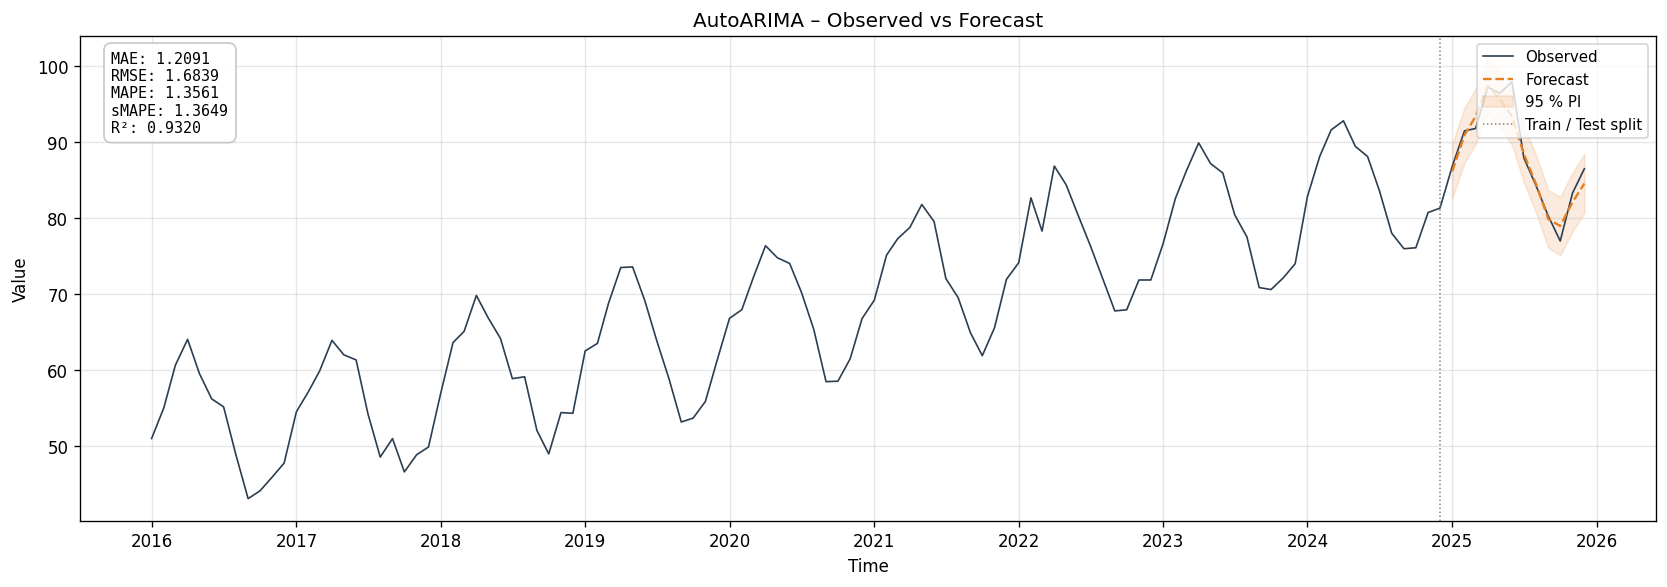

In [34]:
from aic_ts_suite.viz import plot_forecast
from aic_ts_suite.evaluation import compute_all_kpis

kpis_arima = compute_all_kpis(test, res_arima.forecast)

plot_forecast(
    observed=ts,
    forecast=res_arima.forecast,
    lower=res_arima.lower,
    upper=res_arima.upper,
    train_end=train.index[-1],
    kpis=kpis_arima,
    title='AutoARIMA – Observed vs Forecast',
);

---
## 10 — KPI Evaluation & Model Comparison Leaderboard

In [36]:
from aic_ts_suite.evaluation import ModelComparison

cmp = ModelComparison(observed_test=test)
cmp.add(res_arima)
cmp.add(res_ets)
cmp.add(res_hw)
cmp.add(res_xgb)
cmp.add(res_prophet)
cmp.add(res_var)         # VAR forecast (Temperature column)


leaderboard = cmp.leaderboard(sort_by='RMSE')

,MAE,RMSE,MAPE,sMAPE,R²,Duration (ms),correlationId,AICc,AIC,BIC
AutoETS,1.2237,1.6356,1.3793,1.3819,0.9359,"5,161.6000",c288d469-d7d9-4a19-81f2-c0b709091dd3,461.5900,452.9500,503.9100
AutoARIMA,1.2091,1.6839,1.3561,1.3649,0.9320,"36,633.5000",c288d469-d7d9-4a19-81f2-c0b709091dd3,491.8700,491.2800,504.6500
Holt-Winters,1.2191,1.6892,1.3648,1.3735,0.9316,183.3000,c288d469-d7d9-4a19-81f2-c0b709091dd3,136.6000,128.9200,171.8300
Prophet,1.3405,1.7967,1.5028,1.5145,0.9226,"1,190.0000",c288d469-d7d9-4a19-81f2-c0b709091dd3,nan,nan,nan
VAR,1.3664,1.8846,1.5580,1.5546,0.9148,133.2000,c288d469-d7d9-4a19-81f2-c0b709091dd3,nan,1.8200,3.1600
XGBoost,2.7437,3.5228,3.0357,3.0845,0.7024,"2,703.4000",c288d469-d7d9-4a19-81f2-c0b709091dd3,nan,nan,nan


In [37]:
# ── Metric delta tracking (improvement vs. baseline) ──
deltas = cmp.metric_deltas(baseline_model=leaderboard.iloc[0]['Model'])
deltas

,Model,MAE,RMSE,MAPE,sMAPE,R²,Duration (ms)
0,AutoETS,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,AutoARIMA,-0.014581,0.048364,-0.023212,-0.017024,-0.003850,31471.9
2,Holt-Winters,-0.004573,0.053670,-0.014449,-0.008406,-0.004279,-4978.3
3,Prophet,0.116882,0.161168,0.123532,0.132588,-0.013265,-3971.6
4,VAR,0.142734,0.249051,0.178745,0.172711,-0.021023,-5028.4
5,XGBoost,1.520075,1.887194,1.656374,1.702630,-0.233435,-2458.2


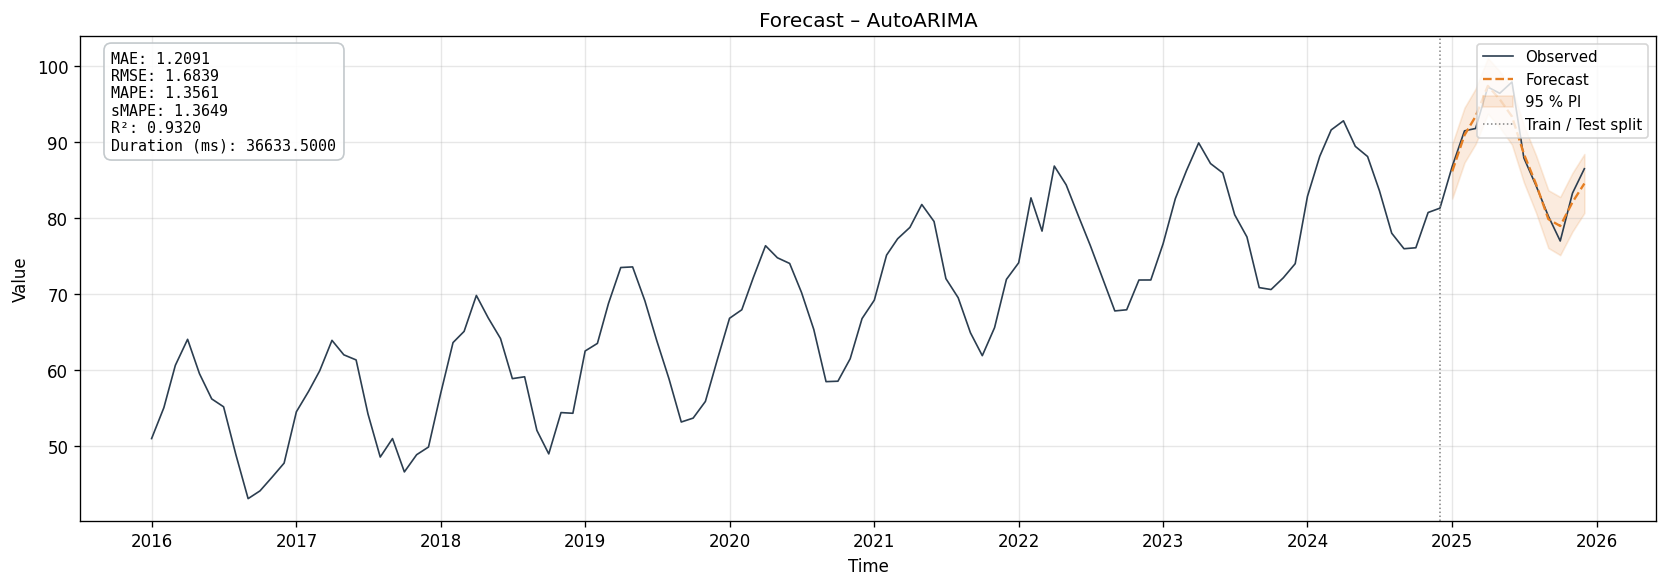

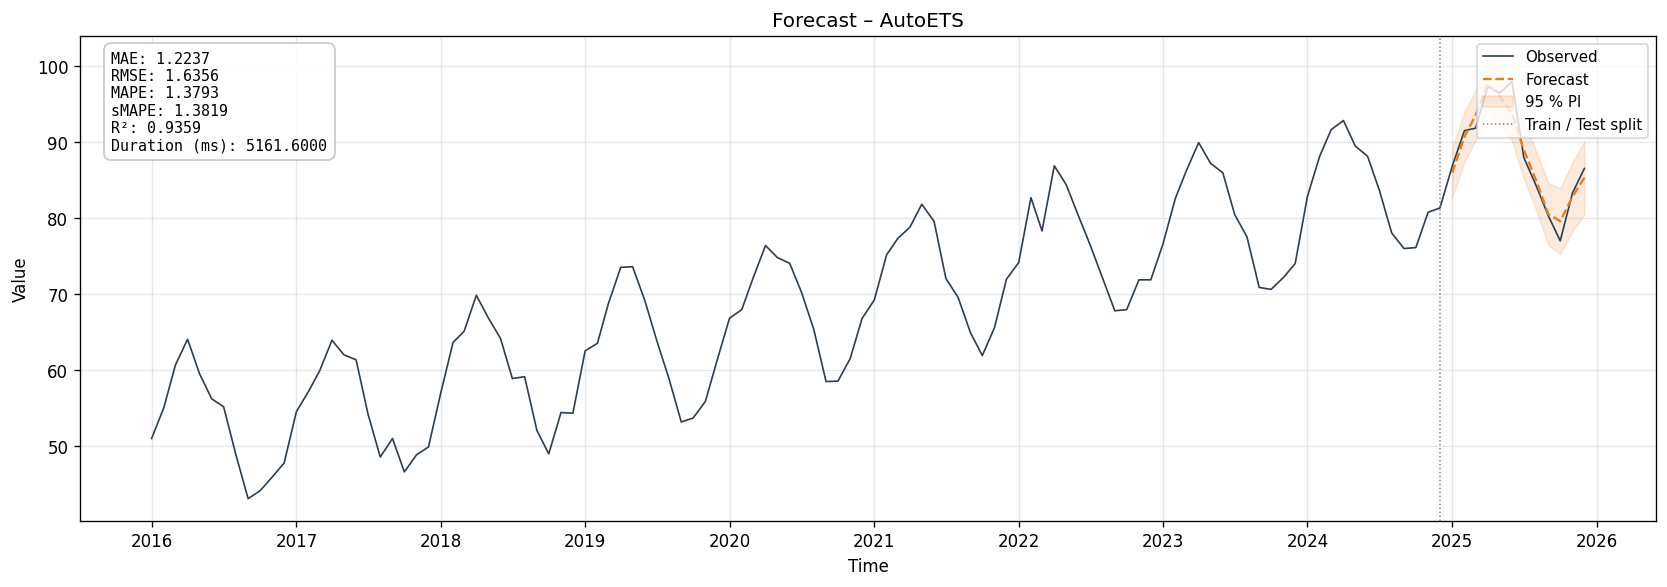

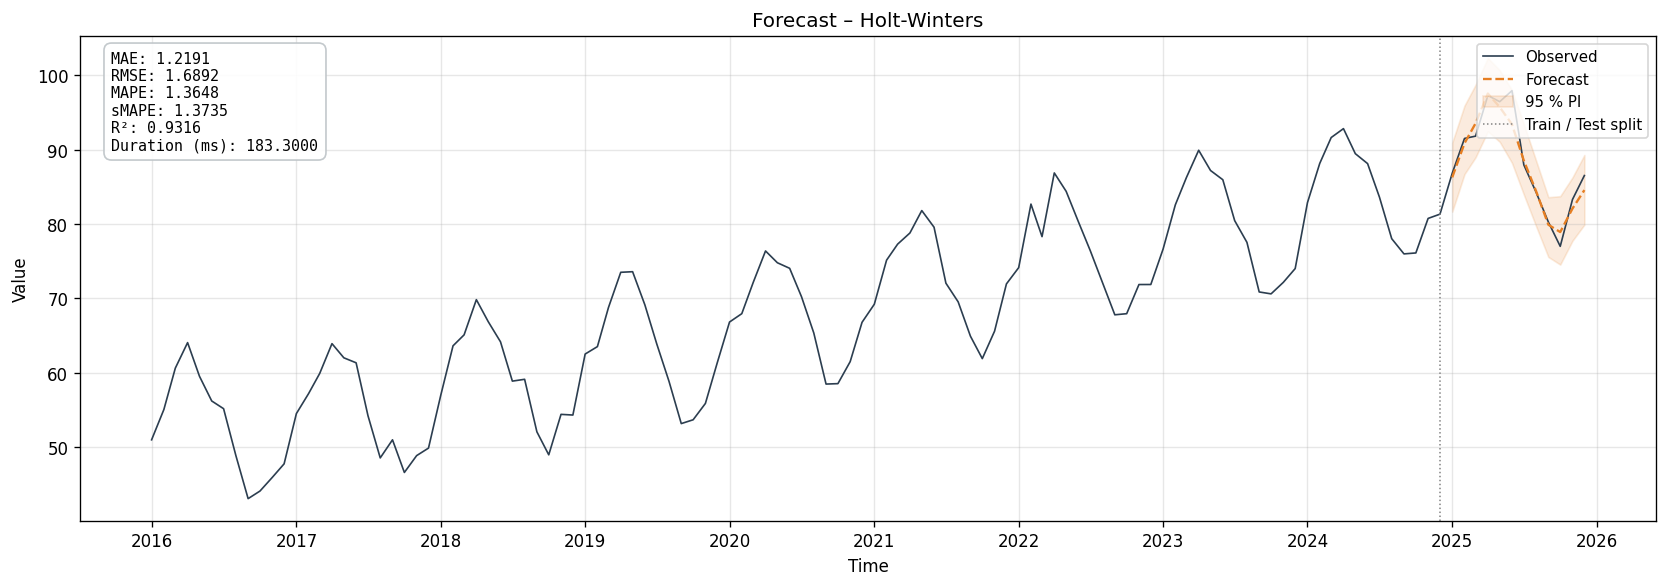

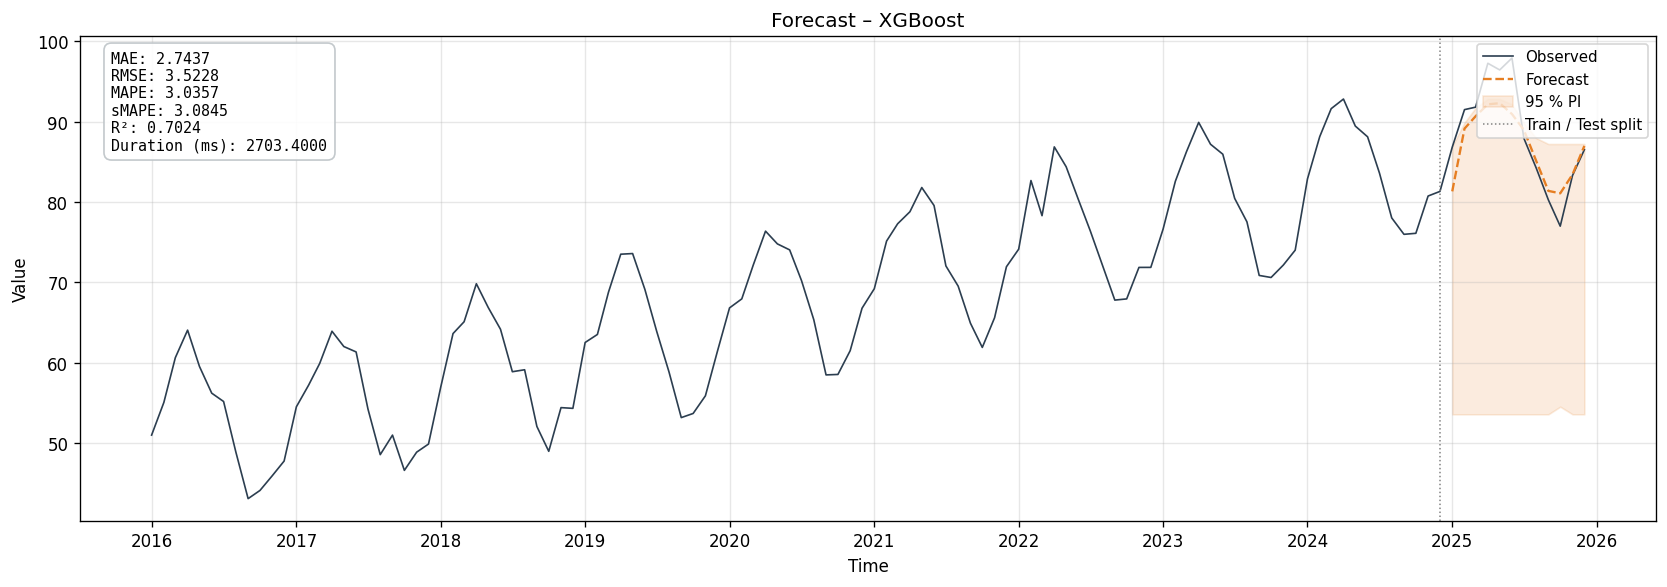

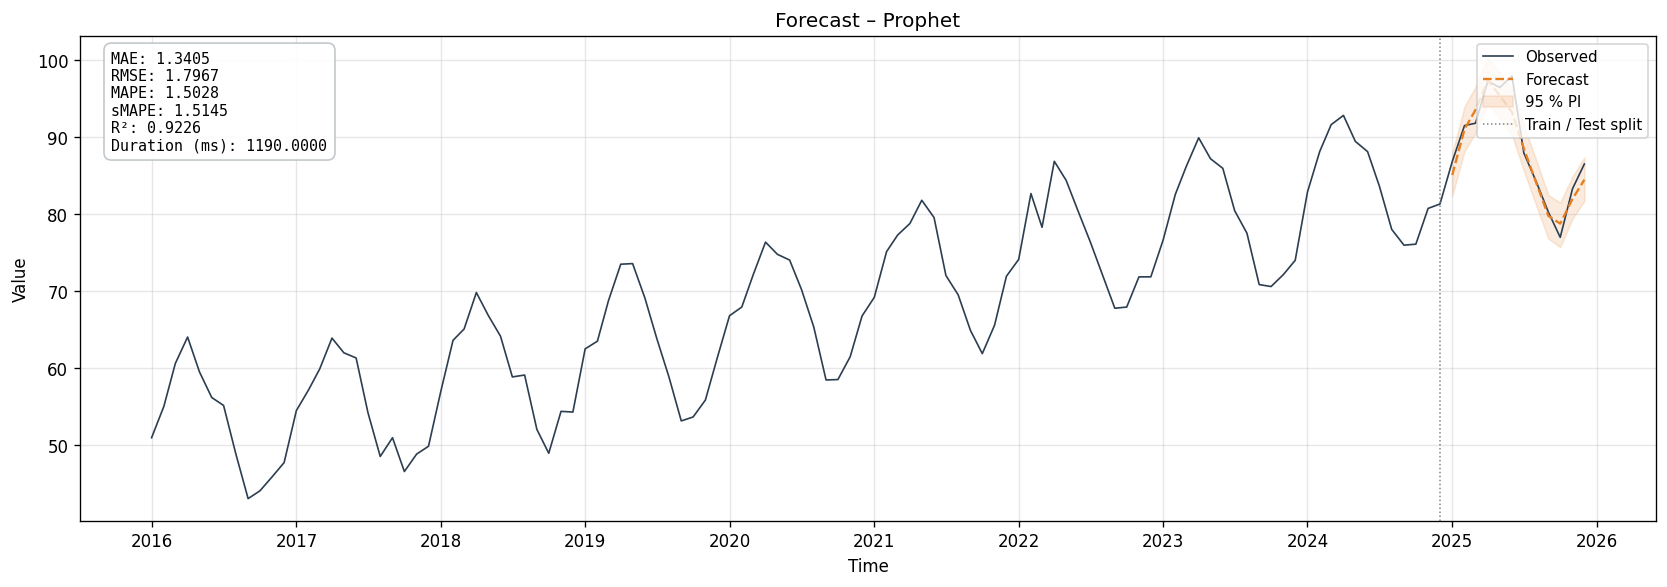

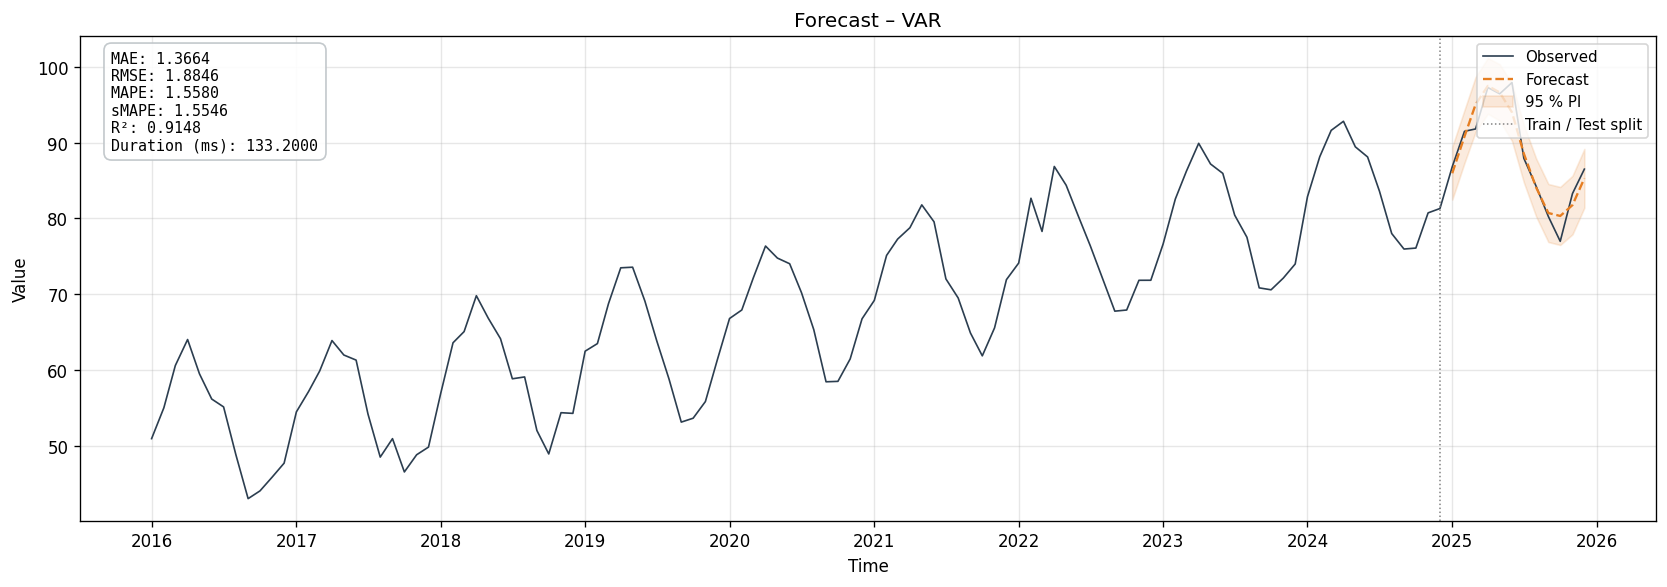

In [38]:
# ── Per-model forecast overlay plots with KPI annotation boxes ──
figs = cmp.plot_all(observed_full=ts, train_end=train.index[-1])

---
## 11 — Styled Display & Metric Cards

In [39]:
from aic_ts_suite.display import styled_summary, metric_cards

# Professional HTML statistical summary
_ = styled_summary(
    ts.describe().to_frame(),
    caption='Temperature – Descriptive Statistics',
)

,Temperature
count,120.0000
mean,69.8389
std,13.2735
min,43.0899
25%,59.4335
50%,70.0201
75%,80.2675
max,97.9097


In [40]:
# Metric cards for best model
best_kpis = compute_all_kpis(test, res_arima.forecast)
best_kpis['Duration (ms)'] = res_arima.duration_ms
best_kpis['correlationId'] = CONFIG.correlation_id[:8] + '…'

_ = metric_cards(best_kpis)

---
## 12 — AnalyticsEngineClient — Run Traceability

In [41]:
from aic_ts_suite.evaluation import AnalyticsEngineClient

client = AnalyticsEngineClient()
client.log_run(res_arima, test)
client.log_run(res_ets, test)
client.log_run(res_hw, test)
client.log_run(res_xgb, test)
client.log_run(res_prophet, test)
client.log_run(res_var, test)

client.summary()

,correlationId,Model,Duration (ms),MAE,RMSE,MAPE,sMAPE,R²,AICc,AIC,BIC
0,c288d469-d7d9-4a19-81f2-c0b709091dd3,AutoARIMA,36633.54,1.209073,1.683921,1.356076,1.364851,0.932004,491.870182,491.281947,504.646091
1,c288d469-d7d9-4a19-81f2-c0b709091dd3,AutoETS,5161.56,1.223653,1.635557,1.379288,1.381874,0.935853,461.586641,452.950278,503.910771
2,c288d469-d7d9-4a19-81f2-c0b709091dd3,Holt-Winters,183.31,1.219080,1.689227,1.364839,1.373468,0.931574,136.603413,128.918020,171.832119
3,c288d469-d7d9-4a19-81f2-c0b709091dd3,XGBoost,2703.39,2.743728,3.522751,3.035662,3.084504,0.702418,NaN,NaN,NaN
4,c288d469-d7d9-4a19-81f2-c0b709091dd3,Prophet,1189.97,1.340536,1.796724,1.502820,1.514463,0.922588,NaN,NaN,NaN
5,c288d469-d7d9-4a19-81f2-c0b709091dd3,VAR,133.19,1.366388,1.884607,1.558033,1.554585,0.914830,NaN,1.820364,3.155962


In [42]:
# JSON export for pipeline integration
print(client.to_json())

[
  {
    "correlation_id": "c288d469-d7d9-4a19-81f2-c0b709091dd3",
    "model_name": "AutoARIMA",
    "duration_ms": 36633.54,
    "kpis": {
      "MAE": 1.20907254818509,
      "RMSE": 1.6839207883328606,
      "MAPE": 1.3560757190801471,
      "sMAPE": 1.364850679341048,
      "R\u00b2": 0.9320035844549325
    },
    "info_criteria": {
      "AICc": 491.8701820553666,
      "AIC": 491.281946761249,
      "BIC": 504.6460909335585
    },
    "extra": {
      "order": "(0, 1, 1)",
      "seasonal_order": "(2, 0, 1, 12)"
    },
    "timestamp_epoch_ms": 1773738813552
  },
  {
    "correlation_id": "c288d469-d7d9-4a19-81f2-c0b709091dd3",
    "model_name": "AutoETS",
    "duration_ms": 5161.56,
    "kpis": {
      "MAE": 1.2236533592252634,
      "RMSE": 1.6355566530563026,
      "MAPE": 1.3792878639620505,
      "sMAPE": 1.3818744826836098,
      "R\u00b2": 0.9358533639172558
    },
    "info_criteria": {
      "AICc": 461.58664139998314,
      "AIC": 452.9502777636195,
      "BIC": 503.

---

### End of Demo

All modules demonstrated. The `correlationId` below traces this entire session:

In [43]:
print(f"Session correlationId: {CONFIG.correlation_id}")

Session correlationId: c288d469-d7d9-4a19-81f2-c0b709091dd3
